# Employee Attrition Prediction using Machine Learning

## Week 2 Internship Project

- Name        : M Karunya sarma
- Internship  : Data Science & Machine Learning Internship
- Week        : Week 2
- Project     : Employee Attrition Prediction using 
Machine Learning

## Project Overview

Employee attrition refers to employees leaving an organization voluntarily or involuntarily. High attrition can result in increased recruitment costs, training expenses, and reduced productivity. This project aims to analyze employee data and build machine learning models that can predict whether an employee is likely to leave the company. The findings can help HR teams identify at-risk employees and take proactive retention measures.

### Objectives

The main objectives of this project are:

- Analyze employee data and understand attrition patterns.
- Identify factors associated with employee turnover.
- Prepare and preprocess data for machine learning.
- Train and compare multiple classification models.
- Evaluate model performance using appropriate metrics.
- Determine the most important factors influencing    attrition.
- Generate actionable HR recommendations based on findings.

### Dataset Information

Dataset Name:
IBM HR Analytics Employee Attrition & Performance Dataset

Source:
Kaggle

Records:
1470 Employees

Target Variable:
Attrition

Target Classes:
Yes  -> Employee Left <br> No   -> Employee Stayed

## Project Workflow

1. Data Loading and Exploration
2. Data Cleaning and Preprocessing
3. Exploratory Data Analysis
4. Feature Engineering
5. Model Building
6. Model Evaluation
7. Feature Importance Analysis
8. Business Insights
9. HR Recommendations

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Model Building
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

### Expected Outcome

By the end of this project, a predictive model will be developed to identify employees who are at higher risk of attrition, enabling HR teams to take preventive actions and improve employee retention.

# Task 1 - Data Loading & Exploration

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/HR_Attrition.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


### First 10 Records

In [4]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


### Dataset Shape

In [5]:
rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

Number of Rows    : 1470
Number of Columns : 35


### Dataset Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

### Target Variable

In [7]:
target_column = "Attrition"

print("Target Variable :", target_column)
print("\nUnique Values:")
print(df[target_column].unique())

Target Variable : Attrition

Unique Values:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


### Attrition Distribution

In [8]:
attrition_counts = df["Attrition"].value_counts()

attrition_counts

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
print("Employees Stayed :", attrition_counts["No"])
print("Employees Left   :", attrition_counts["Yes"])

Employees Stayed : 1233
Employees Left   : 237


### Attrition Rate

In [10]:
attrition_rate = (
    df["Attrition"].value_counts(normalize=True)["Yes"]
) * 100

print(f"Attrition Rate : {attrition_rate:.2f}%")

Attrition Rate : 16.12%


### Feature Type Analysis

In [11]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print("Numeric Columns     :", len(numeric_columns))
print("Categorical Columns :", len(categorical_columns))
print("\nCategorical Features:\n")
print(list(categorical_columns))


Numeric Columns     : 26
Categorical Columns : 9

Categorical Features:

['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


### Statistical Summary

In [12]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Observation

The dataset contains 1,470 employee records and 35 features. Out of 1,470 employees, 237 employees left the company while 1,233 employees stayed. The attrition rate is approximately 16.12%, indicating that employee exits are less frequent compared to employees who remain in the organization. This suggests that the dataset is moderately imbalanced and model evaluation should focus on metrics such as precision, recall and F1-score rather than accuracy alone.

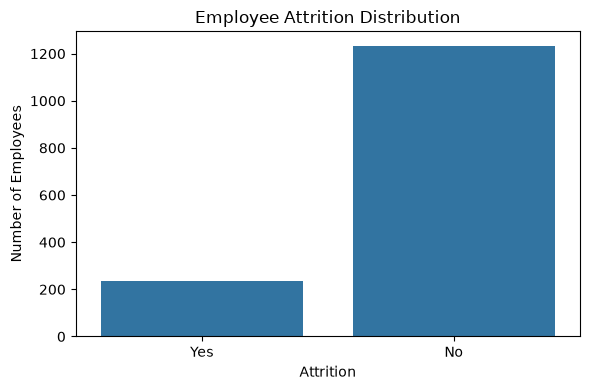

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Attrition",
    data=df
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.tight_layout()

plt.savefig(
    "charts/attrition_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Summary 

The employee attrition dataset contains 1,470 employee records with demographic, job-related, and performance-related features. The target variable is Attrition, which indicates whether an employee left the company. Understanding the dataset structure and feature types helps prepare the data for further analysis and machine learning.

----------------------------------------------

# Task 2 - Data Cleaning & Preprocessing

## Missing Value Analysis

In [14]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [15]:
print("Total Missing Values :", df.isnull().sum().sum())

Total Missing Values : 0


## Constant Feature Analysis

In [16]:
# Check for columns having only one unique value

for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

EmployeeCount
Over18
StandardHours


In [17]:
for column in ["Over18", "StandardHours"]:
    print(f"\n{column}")
    print(df[column].value_counts())


Over18
Over18
Y    1470
Name: count, dtype: int64

StandardHours
StandardHours
80    1470
Name: count, dtype: int64


## Employee Identifier Analysis

In [18]:
print("Unique Employee Numbers :", df["EmployeeNumber"].nunique())
print("Total Records           :", len(df))

Unique Employee Numbers : 1470
Total Records           : 1470


### Observation

The dataset does not contain any missing values. EmployeeCount, Over18 and StandardHours have only one value throughout the dataset, so they do not provide useful information. EmployeeNumber is just an employee ID and is not related to attrition. Therefore, these columns were removed before further processing.

## Removing Non-Predictive Features

In [19]:
df_cleaned = df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ]
)

print("Original Shape :", df.shape)
print("New Shape      :", df_cleaned.shape)

Original Shape : (1470, 35)
New Shape      : (1470, 31)


## Target Variable Encoding

In [20]:
df_cleaned["Attrition"] = df_cleaned["Attrition"].map(
    {
        "Yes": 1,
        "No": 0
    }
)

df_cleaned["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

## Categorical Feature Encoding

In [21]:
categorical_columns = df_cleaned.select_dtypes(
    include=["object"]
).columns

print("Categorical Features:")
print(list(categorical_columns))

Categorical Features:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


### observation 

The categorical features were converted into numerical form using One-Hot Encoding. This makes the data suitable for machine learning algorithms that require numerical inputs.

In [22]:
df_encoded = pd.get_dummies(
    df_cleaned,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Shape Before Encoding :", df_cleaned.shape)
print("Shape After Encoding  :", df_encoded.shape)

Shape Before Encoding : (1470, 31)
Shape After Encoding  : (1470, 45)


In [23]:
df_encoded.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,0,0,0,0,0,1,0,0,1,1
1,49,0,279,8,1,3,61,2,2,2,...,0,0,0,0,1,0,0,1,0,0
2,37,1,1373,2,2,4,92,2,1,3,...,1,0,0,0,0,0,0,0,1,1
3,33,0,1392,3,4,4,56,3,1,3,...,0,0,0,0,1,0,0,1,0,1
4,27,0,591,2,1,1,40,3,1,2,...,1,0,0,0,0,0,0,1,0,0


## Feature Scaling

In [24]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original Shape :", X.shape)
print("Scaled Shape   :", X_scaled.shape)

Original Shape : (1470, 44)
Scaled Shape   : (1470, 44)


In [25]:
X_scaled[:5]

array([[ 0.4463504 ,  0.74252653, -1.01090934, -0.89168825, -0.66053067,
         1.38313827,  0.37967213, -0.05778755,  1.15325359, -0.10834951,
         0.72601994,  2.12513592, -1.1505541 , -0.42623002, -1.58417824,
        -0.93201439, -0.42164246, -2.17198183, -2.49382042, -0.16461311,
        -0.0632959 , -0.67914568,  0.24583399, -0.48185865,  0.63984058,
        -1.37405084,  1.51524392,  1.19404463, -0.34825488, -0.67914108,
        -0.24305927, -0.31409347, -1.22474487, -0.1914977 , -0.46246387,
        -0.27305934, -0.33080804, -0.23990406, -0.49787324,  1.87328654,
        -0.24462499, -0.91892141,  1.45864991,  1.59174553],
       [ 1.32236521, -1.2977746 , -0.14714972, -1.86842575,  0.25462493,
        -0.24067677, -1.02616674, -0.05778755, -0.66085318, -0.29171859,
         1.48887614, -0.67804939,  2.12930601,  2.34615106,  1.19143799,
         0.24198831, -0.1645114 ,  0.15570708,  0.33809616,  0.48850773,
         0.76499762, -0.36871529,  0.80654148,  2.07529738, -1.

### observation

The numerical features were scaled using StandardScaler so that all features are on a similar scale. This prevents features with large values from dominating the model during training.

### Summary 

The dataset was cleaned and prepared for machine learning by checking missing values, removing non-predictive columns, encoding categorical variables, and scaling numerical features. These preprocessing steps ensure that the data is consistent and suitable for model training.

-------------------------------------------------------

# Task 3 – Exploratory Data Analysis (EDA)

## Attrition Distribution



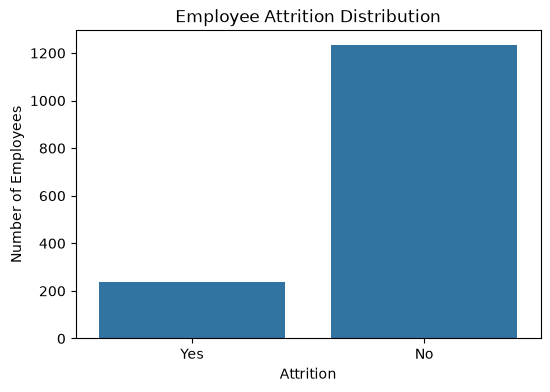

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x="Attrition",
    data=df
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.savefig(
    "charts/attrition_distribution.png",
    bbox_inches="tight"
)

plt.show()

df["Attrition"].value_counts()

## Attrition Rate by Department


In [27]:
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

department_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


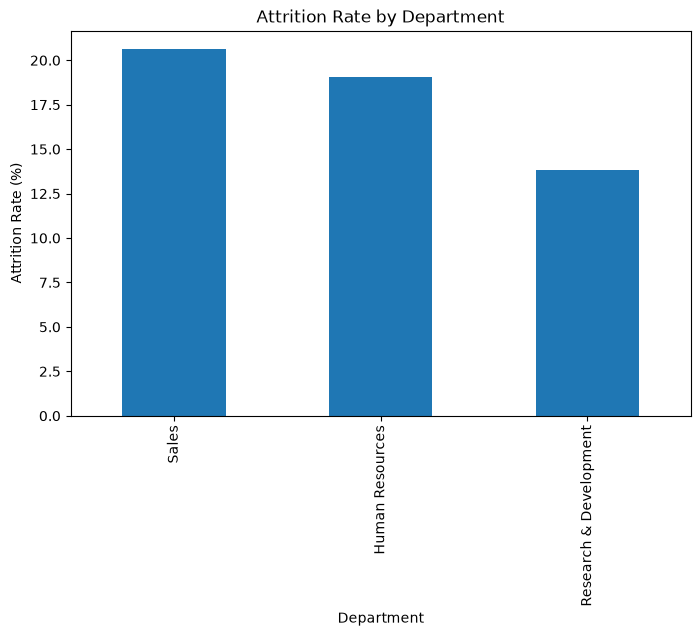

In [28]:
department_attrition["Yes"].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.savefig(
    "charts/attrition_department.png",
    bbox_inches="tight"
)

plt.show()

## Attrition Rate by Job Role



In [29]:
role_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

role_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


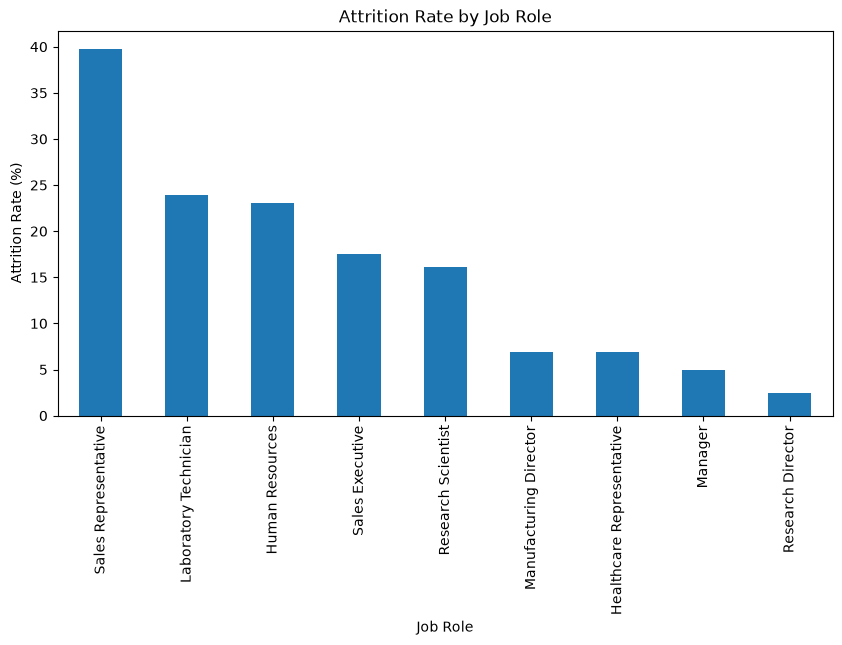

In [30]:
role_attrition["Yes"].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.savefig(
    "charts/attrition_jobrole.png",
    bbox_inches="tight"
)

plt.show()

## Attrition vs Monthly Income



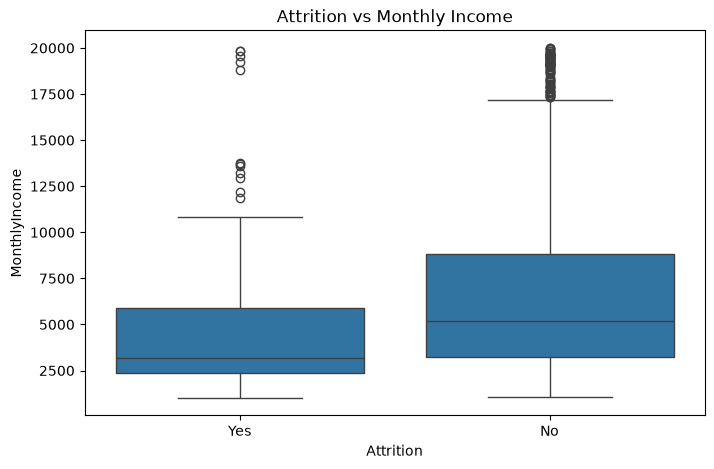

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Attrition vs Monthly Income")

plt.savefig(
    "charts/attrition_income.png",
    bbox_inches="tight"
)

plt.show()

In [32]:
df.groupby("Attrition")["MonthlyIncome"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


## Attrition vs Work-Life Balance



In [33]:
wlb_attrition = pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
) * 100

wlb_attrition

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


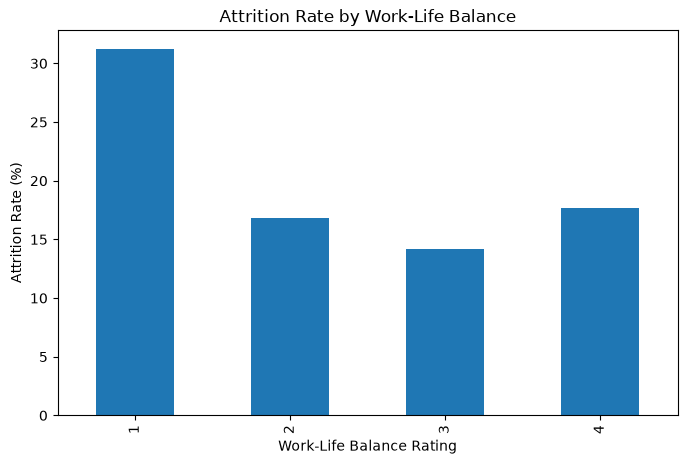

In [34]:
wlb_attrition["Yes"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")

plt.savefig(
    "charts/attrition_worklifebalance.png",
    bbox_inches="tight"
)

plt.show()

## Attrition vs Years at Company

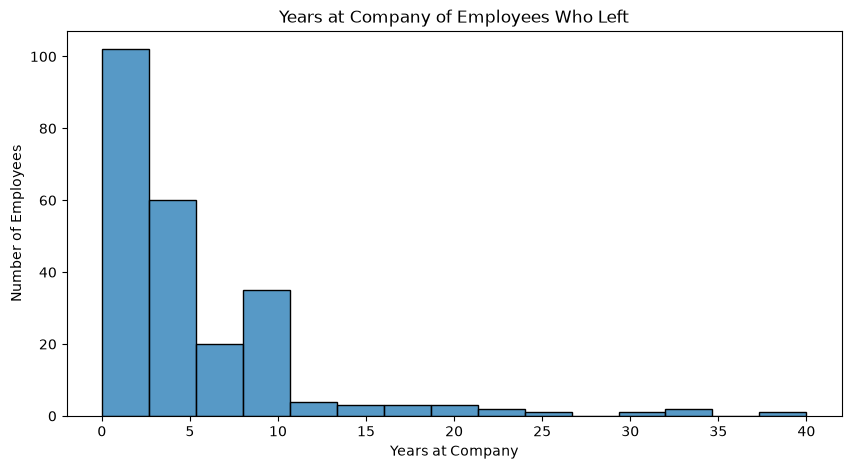

In [35]:
attrition_tenure = df[
    df["Attrition"] == "Yes"
]

plt.figure(figsize=(10,5))

sns.histplot(
    attrition_tenure["YearsAtCompany"],
    bins=15
)

plt.title("Years at Company of Employees Who Left")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")

plt.savefig(
    "charts/attrition_years_company.png",
    bbox_inches="tight"
)

plt.show()

In [36]:
df.groupby("Attrition")["YearsAtCompany"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,7.369019,6.096298,0.0,3.0,6.0,10.0,37.0
Yes,237.0,5.130802,5.949984,0.0,1.0,3.0,7.0,40.0


### observation

The analysis shows that attrition is higher in certain departments and job roles, especially in Sales. Employees who left the company generally had lower monthly income, lower work-life balance ratings, and fewer years at the company compared to employees who stayed. These factors appear to have a noticeable relationship with employee attrition.

## Business Insights

1. The Sales department records the highest attrition rate at approximately 20.63%, making it the department most affected by employee turnover.

2. Sales Representatives have the highest attrition rate among all job roles at approximately 39.76%, which is significantly higher than most other roles.

3. Employees who left the company earned an average monthly income of about 4,787, while retained employees earned about 6,833 on average, indicating that lower-paid employees are more likely to leave.

4. Employees with a Work-Life Balance rating of 1 have an attrition rate of approximately 31.25%, which is nearly double the rate observed for employees with ratings of 2 and 3.

5. Employees who left the company had an average tenure of about 5.13 years, compared to 7.37 years for employees who stayed, suggesting that attrition occurs more frequently during the early years of employment.

### Summary 

The EDA revealed several factors associated with employee attrition. Higher attrition was observed in the Sales department, among Sales Representatives, employees with lower income, lower work-life balance ratings, and employees with fewer years at the company. These patterns provide useful insights into employee turnover behavior.

---------------------------------------------------------

# Task 4 — Model Building & Comparison

### Data Preparation & Train-Test Split

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

label_encoders = {}

for col in df_model.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

X = df_model.drop("Attrition", axis=1)
y = df_model["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 1176
Testing Samples: 294


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling applied successfully.")

Scaling applied successfully.


### Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(
    C=0.05,
    class_weight="balanced",
    solver="liblinear",
    max_iter=5000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2))

Logistic Regression Accuracy: 74.49


### Random Forest Classifier

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2))

Random Forest Accuracy: 83.67


### Gradient Boosting Classifier

In [41]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy:", round(gb_accuracy * 100, 2))

Gradient Boosting Accuracy: 86.05


### Model Comparison

In [42]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy (%)": [
        round(lr_accuracy * 100, 2),
        round(rf_accuracy * 100, 2),
        round(gb_accuracy * 100, 2)
    ]
})

comparison.sort_values(
    by="Accuracy (%)",
    ascending=False,
    inplace=True
)

comparison.reset_index(drop=True, inplace=True)

comparison

,Model,Accuracy (%)
0,Gradient Boosting,86.05
1,Random Forest,83.67
2,Logistic Regression,74.49


### Accuracy Comparison Chart

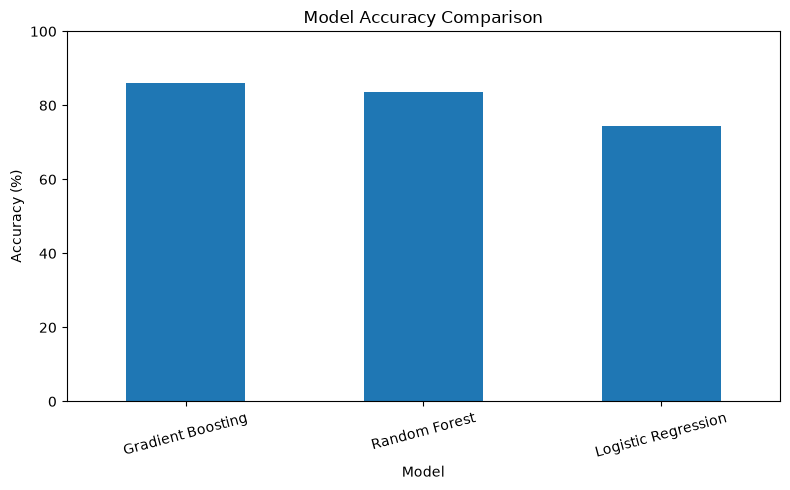

In [43]:
import matplotlib.pyplot as plt

comparison.plot(
    x="Model",
    y="Accuracy (%)",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=15)
plt.ylim(0, 100)

plt.tight_layout()

plt.savefig(
    "charts/model_comparison.png",
    bbox_inches="tight"
)

plt.show()

### Observation

The three machine learning models showed different levels of performance in predicting employee attrition. Logistic Regression achieved an accuracy of 74.49%, while Random Forest improved the accuracy to 83.67%. Gradient Boosting performed the best with an accuracy of 86.05%. The results indicate that ensemble-based models are more effective than the baseline Logistic Regression model for this dataset.

### Business Insights

1. Gradient Boosting achieved the highest prediction accuracy of 86.05%, making it the most suitable model for employee attrition prediction.
2. Random Forest also performed well with 83.67% accuracy, showing that tree-based ensemble methods capture attrition patterns effectively.
3. Logistic Regression achieved 74.49% accuracy and can serve as a simple, interpretable baseline model for HR teams.
4. The accuracy difference between Logistic Regression and Gradient Boosting is over 11 percentage points, highlighting the benefit of using advanced machine learning techniques.
5. The strong performance of Gradient Boosting suggests that employee attrition is influenced by complex relationships among multiple factors rather than simple linear patterns.

### Summary

Three machine learning models were trained and evaluated using an 80/20 train-test split with class balancing. Among the models, Gradient Boosting achieved the highest accuracy (86.05%), followed by Random Forest (83.67%) and Logistic Regression (74.49%). Based on the comparison, Gradient Boosting was selected as the best-performing model for predicting employee attrition.

------------------------

# Task 5 — Model Evaluation

### Requirements

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pandas as pd
import matplotlib.pyplot as plt

### Logistic Regression Evaluation

In [45]:
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

lr_accuracy = accuracy_score(y_test, lr_pred)

lr_auc = roc_auc_score(
    y_test,
    lr_model.predict_proba(X_test_scaled)[:, 1]
)

print("Precision:", round(lr_precision, 4))
print("Recall:", round(lr_recall, 4))
print("F1 Score:", round(lr_f1, 4))
print("ROC AUC:", round(lr_auc, 4))
print("Accuracy:", round(lr_accuracy, 4))

Precision: 0.3627
Recall: 0.7872
F1 Score: 0.4966
ROC AUC: 0.8027
Accuracy: 0.7449


### Logistic Regression Confusion Matrix

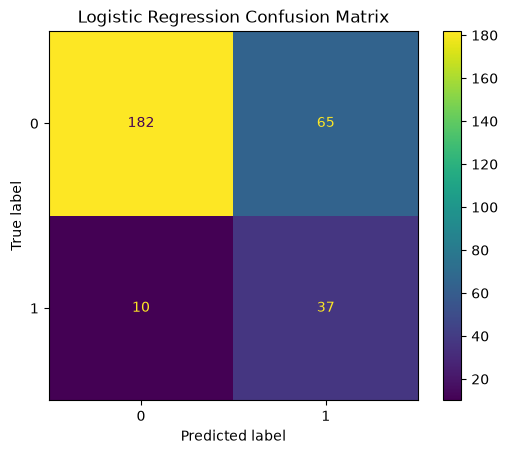

In [46]:
cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")

plt.savefig(
    "charts/logistic_regression_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

### Random Forest Evaluation

In [47]:
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_auc = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test)[:, 1]
)

print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1 Score:", round(rf_f1, 4))
print("ROC AUC:", round(rf_auc, 4))
print("Accuracy:", round(rf_accuracy, 4))

Precision: 0.4865
Recall: 0.383
F1 Score: 0.4286
ROC AUC: 0.7874
Accuracy: 0.8367


### Random Forest Confusion Matrix

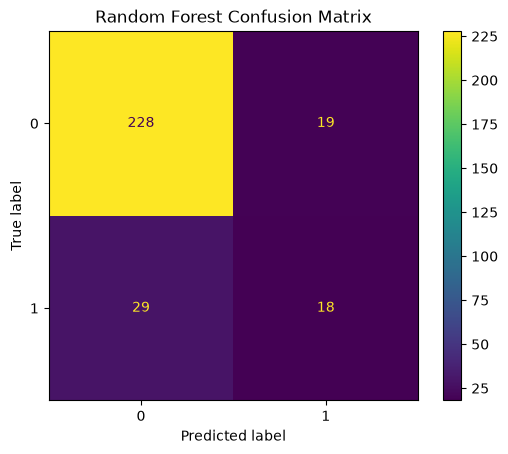

In [48]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.savefig(
    "charts/random_forest_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

### Gradient Boosting Evaluation

In [49]:
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_accuracy = accuracy_score(y_test, gb_pred)

gb_auc = roc_auc_score(
    y_test,
    gb_model.predict_proba(X_test)[:, 1]
)

print("Precision:", round(gb_precision, 4))
print("Recall:", round(gb_recall, 4))
print("F1 Score:", round(gb_f1, 4))
print("ROC AUC:", round(gb_auc, 4))
print("Accuracy:", round(gb_accuracy, 4))

Precision: 0.6875
Recall: 0.234
F1 Score: 0.3492
ROC AUC: 0.8093
Accuracy: 0.8605


### Gradient Boosting Confusion Matrix

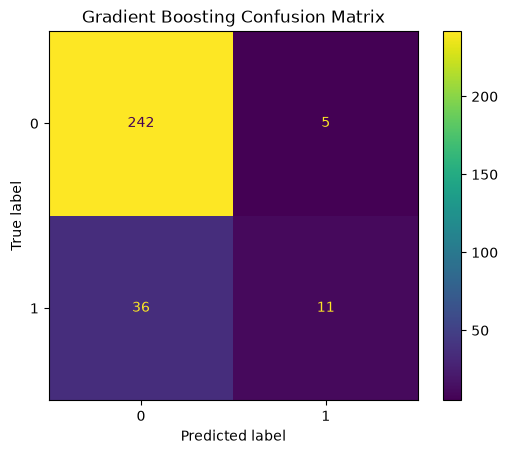

In [50]:
cm = confusion_matrix(y_test, gb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Gradient Boosting Confusion Matrix")

plt.savefig(
    "charts/gradient_boosting_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

### Model Evaluation Comparison

In [51]:
evaluation_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        gb_accuracy
    ],

    "Precision": [
        lr_precision,
        rf_precision,
        gb_precision
    ],

    "Recall": [
        lr_recall,
        rf_recall,
        gb_recall
    ],

    "F1 Score": [
        lr_f1,
        rf_f1,
        gb_f1
    ],

    "ROC-AUC": [
        lr_auc,
        rf_auc,
        gb_auc
    ]
})

### Evaluation Metrics Visualization

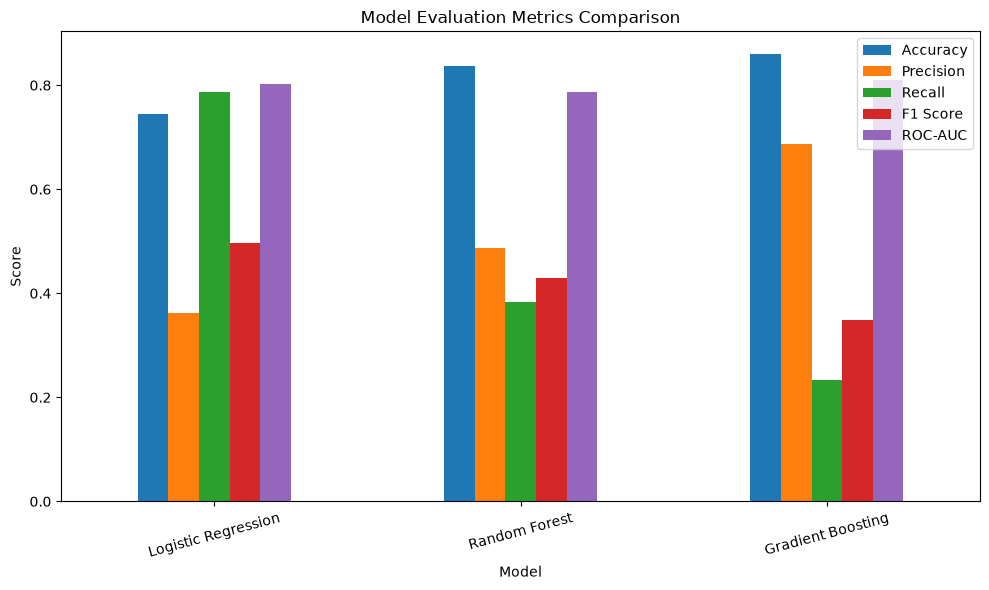

In [52]:
evaluation_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Evaluation Metrics Comparison")
plt.ylabel("Score")
plt.xlabel("Model")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "charts/model_evaluation_comparison.png",
    bbox_inches="tight"
)

plt.show()

### Best Model Selection

Gradient Boosting achieved the highest classification accuracy (86.05%) and the highest ROC-AUC score (0.8093), indicating strong capability in distinguishing employees who are likely to leave from those who are likely to stay.

Although Logistic Regression achieved a higher Recall score (0.7872), Gradient Boosting demonstrated better overall predictive performance through superior Accuracy, Precision, and ROC-AUC scores.

Therefore, Gradient Boosting is selected as the best-performing model for employee attrition prediction.

### Feature Importance Analysis

In [53]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
21,OverTime,0.115980
17,MonthlyIncome,0.104423
27,TotalWorkingYears,0.089454
0,Age,0.079288
14,JobRole,0.061322
26,StockOptionLevel,0.049707
2,DailyRate,0.045029
9,EnvironmentSatisfaction,0.044619
33,YearsWithCurrManager,0.044459
19,NumCompaniesWorked,0.041003


### Top 10 Feature Importance

In [54]:
top10_features = feature_importance.head(10)

top10_features

,Feature,Importance
21,OverTime,0.115980
17,MonthlyIncome,0.104423
27,TotalWorkingYears,0.089454
0,Age,0.079288
14,JobRole,0.061322
26,StockOptionLevel,0.049707
2,DailyRate,0.045029
9,EnvironmentSatisfaction,0.044619
33,YearsWithCurrManager,0.044459
19,NumCompaniesWorked,0.041003


### Feature Importance Visualization

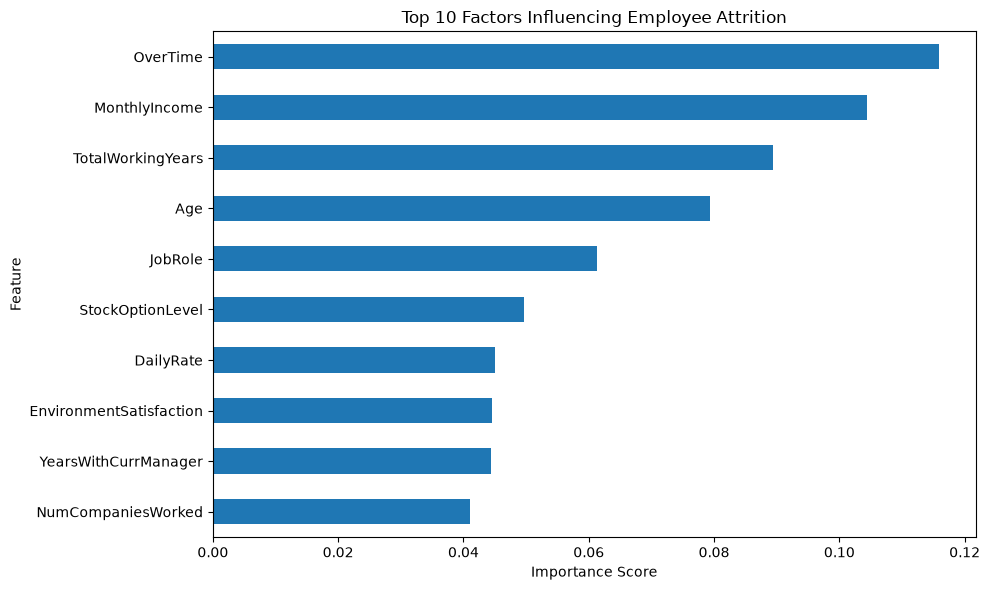

In [55]:
top10_features.sort_values(
    by="Importance",
    ascending=True
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10,6),
    legend=False
)

plt.title("Top 10 Factors Influencing Employee Attrition")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "charts/top10_feature_importance.png",
    bbox_inches="tight"
)

plt.show()

### Feature Importance Observations

1. OverTime is the most influential factor affecting employee attrition.

2. MonthlyIncome is the second most important feature, suggesting compensation strongly impacts employee retention.

3. Employees with fewer TotalWorkingYears appear more likely to leave compared to experienced employees.

4. Age plays a significant role, indicating attrition patterns vary across different age groups.

5. JobRole contributes notably to attrition, implying some roles experience higher turnover than others.

6. StockOptionLevel influences retention, showing that employee benefits can affect long-term commitment.

7. EnvironmentSatisfaction impacts attrition, highlighting the importance of workplace conditions.

8. YearsWithCurrManager suggests employee-manager relationships contribute to retention decisions.

9. Employees who worked in multiple companies previously tend to show different attrition behavior.

10. Attrition is driven by a combination of financial, career-growth, and workplace-environment factors.

### Task 5 Summary

Three machine learning models were evaluated for employee attrition prediction: Logistic Regression, Random Forest, and Gradient Boosting.

Evaluation was performed using Precision, Recall, F1-Score, ROC-AUC Score, and Confusion Matrices.

Gradient Boosting achieved the highest classification accuracy (86.05%) and highest ROC-AUC score (0.8093), making it the best-performing model overall.

Feature importance analysis revealed that OverTime, MonthlyIncome, TotalWorkingYears, Age, and JobRole were the strongest predictors of employee attrition.

These findings indicate that employee workload, compensation, experience, and workplace satisfaction significantly influence employee retention.

--------

# Task 6 — Visualization

### Note:

Chart 3 (Confusion Matrix Heatmap) and Chart 4 (Top 10 Feature Importance)
were generated in Task 5 during model evaluation and feature importance analysis.
They are included as part of the visualization requirements for Task 6.

### Chart 1 — Attrition Rate by Department and Job Role

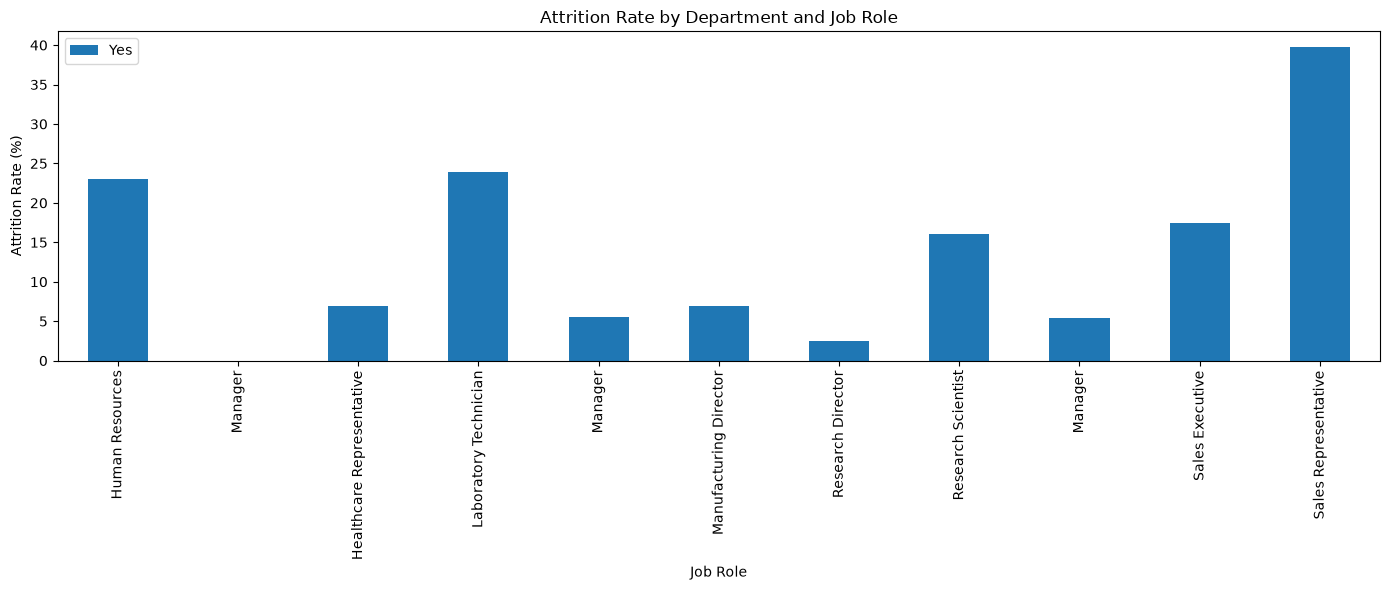

In [56]:
attrition_dept_role = pd.crosstab(
    [df["Department"], df["JobRole"]],
    df["Attrition"],
    normalize="index"
) * 100

attrition_dept_role = attrition_dept_role.reset_index()

attrition_dept_role.plot(
    x="JobRole",
    y="Yes",
    kind="bar",
    figsize=(14,6)
)

plt.title("Attrition Rate by Department and Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Job Role")

plt.tight_layout()

plt.savefig(
    "charts/attrition_department_jobrole.png",
    bbox_inches="tight"
)

plt.show()

### Chart 2 — Monthly Income Box Plot

<Figure size 800x600 with 0 Axes>

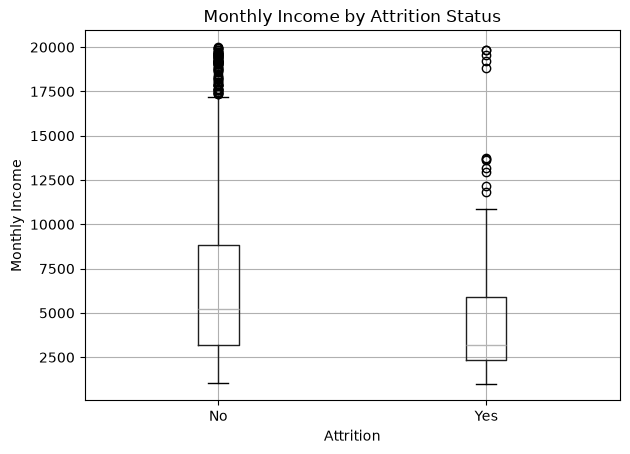

In [57]:
plt.figure(figsize=(8,6))

df.boxplot(
    column="MonthlyIncome",
    by="Attrition"
)

plt.title("Monthly Income by Attrition Status")
plt.suptitle("")

plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.tight_layout()

plt.savefig(
    "charts/attrition_income_boxplot.png",
    bbox_inches="tight"
)

plt.show()

### Chart 5 (Bonus) — ROC Curve Comparison

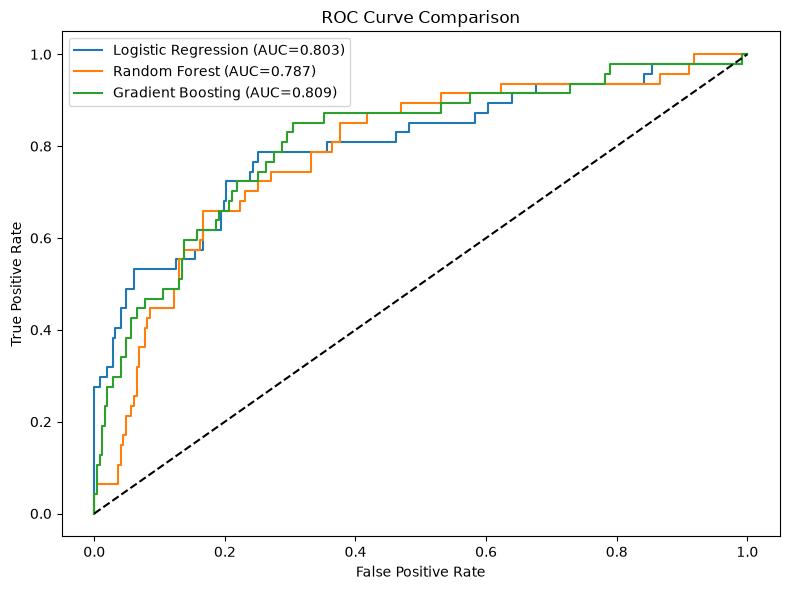

In [58]:
from sklearn.metrics import roc_curve

lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_model.predict_proba(X_test_scaled)[:,1]
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_model.predict_proba(X_test)[:,1]
)

gb_fpr, gb_tpr, _ = roc_curve(
    y_test,
    gb_model.predict_proba(X_test)[:,1]
)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={lr_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={rf_auc:.3f})"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label=f"Gradient Boosting (AUC={gb_auc:.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/roc_curve_comparison.png",
    bbox_inches="tight"
)

plt.show()

-----

# Task 7 — HR Insights & Business Recommendations

### HR Insights & Business Recommendations

The analysis shows that employees who work overtime frequently, earn lower salaries, and have different levels of work experience are more likely to leave the company. Among all job roles, Sales Representatives showed the highest employee turnover and should be given special attention by the HR team.

While salary has an impact on employee retention, it is not the only reason employees leave. Workload, job role, work experience, and overall job satisfaction also appear to influence employee turnover. This suggests that increasing salary alone may not completely solve the attrition problem.

Based on these findings, the company should focus on reducing excessive overtime and improving work-life balance for employees. HR can also conduct regular check-ins with employees in high-turnover roles, such as Sales Representatives, to understand their concerns and provide better career growth opportunities.

One limitation of this analysis is that it is based on past employee records. Personal reasons, future organizational changes, and external factors cannot be captured in the data. Therefore, the results should be used to support HR decisions rather than replace human judgment.


---